# Stuttering Detection: Advanced Neural Network Analysis
---

In [27]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from src.data import DataManager
from src.extractors import WavLMExtractor
from src.models import ShallowNeuralNetwork, DeepNeuralNetwork
from sklearn.decomposition import PCA

## Step 2: Configuration & Operational Flags

In [28]:
# Constants
SAMPLE_LIMIT = None
STRICT_LABELS = True # Set to True to filter out ambiguous samples (Score 1 & 2)
RANDOM_SEED = 42
CSV_PATHS = [
    "Stuttering Events in Podcasts Dataset/SEP-28k_labels.csv",
    "Stuttering Events in Podcasts Dataset/fluencybank_labels.csv"
]
AUDIO_DIR = "Stuttering Events in Podcasts Dataset/clips/stuttering-clips/clips"
FEATURE_DIR = "data/features"
fluent_dir = os.path.join(FEATURE_DIR, "fluent")
disfluent_dir = os.path.join(FEATURE_DIR, "disfluent")

# Operational Flags
SKIP_EXTRACTION = True
FORCE_EXTRACT = False
CLEAN_START = False
NUM_CLIPS_TO_EXTRACT = 1000

## Step 3: (Optional) Data Extraction Process

In [29]:
if not SKIP_EXTRACTION or CLEAN_START or FORCE_EXTRACT:
    import shutil
    if CLEAN_START and os.path.exists(FEATURE_DIR):
        shutil.rmtree(FEATURE_DIR)
        print("[System] Feature database wiped for clean start.")
    
    extractor = WavLMExtractor("microsoft/wavlm-base")
    label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
    
    extractor.extract_from_dir(
        AUDIO_DIR, 
        output_dir=FEATURE_DIR, 
        label_dict=label_dict, 
        limit=NUM_CLIPS_TO_EXTRACT, 
        random_sample=True
    )
else:
    print("[System] Skipping extraction. Using existing data on disk.")

[System] Skipping extraction. Using existing data on disk.


## Step 4: Standardized Data Loading & Splitting

In [30]:
# Standardized Data Loading
label_dict = DataManager.generate_label_dict(CSV_PATHS, filter_quality=True, strict=STRICT_LABELS)
manager = DataManager(None, None)

X, y = manager.load_from_folders(fluent_dir, disfluent_dir, limit=SAMPLE_LIMIT, label_dict=label_dict)
X_train, X_val, X_test, y_train, y_val, y_test = manager.get_splits(test_size=0.15, val_size=0.15)

# Balance training data (Fixes class mismatch errors)
X_train_bal, y_train_bal = manager.balance_data(X_train, y_train, strategy="oversample")

# Preprocessing (Zero-Leakage)
X_train_final = manager.preprocess(X_train_bal, method="standard", fit=True)
X_val_final = manager.preprocess(X_val, method="standard", fit=False)
X_test_final = manager.preprocess(X_test, method="standard", fit=False)

print(f"Data Ready: {len(X_train_final)} balanced training samples.")


[DataManager] Quality Filter: Removed 3938 low-quality samples.
[DataManager] Strict Filter: Kept 16109 high-agreement samples (Removed 12274 ambiguous samples).
[DataManager] Strict Filtering: Kept 14452 high-agreement samples (Discarded 11361 ambiguous samples).
Data Ready: 10896 balanced training samples.


In [31]:
# --- Baseline: Shallow Neural Network ---
print("--- Training Shallow NN Baseline ---")
shallow_nn = ShallowNeuralNetwork("Shallow_NN_Baseline", input_size=X_train_final.shape[1])
shallow_nn.train(X_train_final, y_train_bal, epochs=20, lr=0.001)

print("\n--- Evaluation: Shallow NN ---")
shallow_nn.evaluate(X_test_final, y_test)

# --- Baseline: Deep Neural Network ---
print("--- Training Deep NN Baseline ---")
deep_nn = DeepNeuralNetwork("Deep_NN_Baseline", input_size=X_train_final.shape[1])
deep_nn.train(X_train_final, y_train_bal, epochs=30, lr=0.001)

print("\n--- Evaluation: Deep NN ---")
deep_nn.evaluate(X_test_final, y_test)


--- Training Shallow NN Baseline ---
[Model: Shallow_NN_Baseline] Initialized.
[Shallow_NN_Baseline] Training PyTorch Network (Layers: [100]) for 20 epochs...

--- Evaluation: Shallow NN ---

--- Evaluation: Shallow_NN_Baseline ---
Accuracy: 0.8040
Precision: 0.7889
Recall: 0.7850
F1: 0.7870

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      958             210            
True: Stutter(1)     215             785            
--- Training Deep NN Baseline ---
[Model: Deep_NN_Baseline] Initialized.
[Deep_NN_Baseline] Training PyTorch Network (Layers: (100, 50)) for 30 epochs...

--- Evaluation: Deep NN ---

--- Evaluation: Deep_NN_Baseline ---
Accuracy: 0.8063
Precision: 0.8027
Recall: 0.7690
F1: 0.7855

Confusion Matrix (Binary):
               Predicted: Fluent(0)  Predicted: Stutter(1)
True: Fluent(0)      979             189            
True: Stutter(1)     231             769            


{'accuracy': 0.8062730627306273,
 'precision': 0.802713987473904,
 'recall': 0.769,
 'f1': 0.7854954034729316,
 'confusion_matrix': array([[979, 189],
        [231, 769]])}

## Step 5: Optimized MLP Architecture
Uses BatchNorm, Dropout, and ReLU to prevent vanishing gradients and overfitting.

In [32]:
class AdvancedStutterNet(nn.Module):
    def __init__(self, config):
        super(AdvancedStutterNet, self).__init__()
        layers = []
        input_dim = config['num_features']
        
        # Pro Dynamic Architecture Construction
        for i, hidden_dim in enumerate(config['hidden_layers']):
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            # Use the first dropout rate for the first layer, second for others
            drop_idx = min(i, len(config['dropout_rates']) - 1)
            layers.append(nn.Dropout(config['dropout_rates'][drop_idx]))
            input_dim = hidden_dim
            
        layers.append(nn.Linear(input_dim, 1)) # Final binary output
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x)


## Step 6: Training with History Diagnostics

In [33]:
# --- FUNCTIONAL HYPERPARAMETER CONTROL CENTER ---
config = {
    "num_features": X_train_final.shape[1],
    "hidden_layers": [256, 128, 64],
    "dropout_rates": [0.3, 0.2],
    "learning_rate": 0.001,
    "epochs": 150
}

def train_stutternet(model, X_train, y_train, X_val, y_val, config):
    X_t, y_t = torch.FloatTensor(X_train), torch.FloatTensor(y_train).view(-1, 1)
    X_v, y_v = torch.FloatTensor(X_val), torch.FloatTensor(y_val).view(-1, 1)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    
    print(f"--- Starting Optimization ({config['epochs']} Epochs) ---")
    for epoch in range(config['epochs']):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_t), y_t)
        loss.backward()
        optimizer.step()
        
        model.eval()
        with torch.no_grad():
            v_out = model(X_v)
            v_loss = criterion(v_out, y_v)
            v_acc = ((torch.sigmoid(v_out) > 0.5).float() == y_v).float().mean()
            
        history['train_loss'].append(loss.item())
        history['val_loss'].append(v_loss.item())
        history['val_acc'].append(v_acc.item())
        
        if (epoch + 1) % 25 == 0:
            print(f"Epoch {epoch+1:03d} | Loss: {loss.item():.4f} | Val Acc: {v_acc.item():.4f}")
    return history

advanced_model = AdvancedStutterNet(config)
history = train_stutternet(advanced_model, X_train_final, y_train_bal, X_val_final, y_val, config)


--- Starting Optimization (150 Epochs) ---
Epoch 025 | Loss: 0.3151 | Val Acc: 0.8256
Epoch 050 | Loss: 0.1491 | Val Acc: 0.8293
Epoch 075 | Loss: 0.0702 | Val Acc: 0.8270
Epoch 100 | Loss: 0.0431 | Val Acc: 0.8187
Epoch 125 | Loss: 0.0238 | Val Acc: 0.8233
Epoch 150 | Loss: 0.0175 | Val Acc: 0.8303


In [34]:
import os
os.makedirs("reports", exist_ok=True)
# --- DYNAMIC MASTER GRID STUDY (Width vs. Depth) ---
study_grid = {
    'architectures': [[1024, 512], [512, 256], [1024], [512]],
    'learning_rates': [0.005, 0.001]
}

best_acc = 0
best_config = {}
study_results = [] # NEW: To collect data for the CSV

print("| Trial | Depth | Width | LR     | Val Acc |")
print("|-------|-------|-------|--------|---------|")

trial = 1
for arch in study_grid['architectures']:
    for lr in study_grid['learning_rates']:
        config['hidden_layers'] = arch
        config['learning_rate'] = lr
        m = AdvancedStutterNet(config)
        h = train_stutternet(m, X_train_final, y_train_bal, X_val_final, y_val, config)
        
        acc = h['val_acc'][-1]
        depth = len(arch)
        print(f"| {trial:02d}    | {depth}     | {arch[0]} | {lr:.4f} | {acc:.4f}  |")
        
        # NEW: Store result for report
        study_results.append({
            'trial': trial, 'depth': depth, 'width': arch[0], 'lr': lr, 'val_accuracy': acc
        })
        
        if acc > best_acc:
            best_acc = acc
            best_config = config.copy()
        trial += 1

# NEW: Export results to CSV for the leaderboard
pd.DataFrame(study_results).to_csv("reports/nn_hypertuning_benchmarks.csv", index=False)
print(f"\n[System] Benchmarking data saved to reports/nn_hypertuning_benchmarks.csv")

config = best_config
print(f"\n[System] Optimization Complete. Best Depth: {len(config['hidden_layers'])} with Width: {config['hidden_layers'][0]}")


| Trial | Depth | Width | LR     | Val Acc |
|-------|-------|-------|--------|---------|
--- Starting Optimization (150 Epochs) ---
Epoch 025 | Loss: 0.4387 | Val Acc: 0.7906
Epoch 050 | Loss: 0.3671 | Val Acc: 0.8086
Epoch 075 | Loss: 0.2425 | Val Acc: 0.8192
Epoch 100 | Loss: 0.0786 | Val Acc: 0.8215
Epoch 125 | Loss: 0.0242 | Val Acc: 0.8067
Epoch 150 | Loss: 0.0128 | Val Acc: 0.8090
| 01    | 2     | 1024 | 0.0050 | 0.8090  |
--- Starting Optimization (150 Epochs) ---
Epoch 025 | Loss: 0.1751 | Val Acc: 0.8238
Epoch 050 | Loss: 0.0312 | Val Acc: 0.8344
Epoch 075 | Loss: 0.0089 | Val Acc: 0.8238
Epoch 100 | Loss: 0.0051 | Val Acc: 0.8261
Epoch 125 | Loss: 0.0033 | Val Acc: 0.8252
Epoch 150 | Loss: 0.0035 | Val Acc: 0.8307
| 02    | 2     | 1024 | 0.0010 | 0.8307  |
--- Starting Optimization (150 Epochs) ---
Epoch 025 | Loss: 0.3922 | Val Acc: 0.8072
Epoch 050 | Loss: 0.2660 | Val Acc: 0.8289
Epoch 075 | Loss: 0.1007 | Val Acc: 0.8196
Epoch 100 | Loss: 0.0296 | Val Acc: 0.8224
Epoch

In [35]:
# --- STEP 6.5: FINAL TRAINING WITH BEST HYPERPARAMETERS ---
# We take the 'best_config' discovered in the grid study and train a fresh model
print("[System] Re-training final model with optimized parameters...")
print(f"Target Configuration: Depth {len(config['hidden_layers'])}, Width {config['hidden_layers'][0]}, LR {config['learning_rate']}")

# 1. Initialize fresh model with best config
advanced_model = AdvancedStutterNet(config)

# 2. Train for the full 150 epochs to capture maximum learning
history = train_stutternet(
    advanced_model, 
    X_train_final, 
    y_train_bal, 
    X_val_final, 
    y_val, 
    config
)

print("\n[System] Final Optimized Training Complete.")


[System] Re-training final model with optimized parameters...
Target Configuration: Depth 2, Width 1024, LR 0.001
--- Starting Optimization (150 Epochs) ---
Epoch 025 | Loss: 0.1901 | Val Acc: 0.8233
Epoch 050 | Loss: 0.0345 | Val Acc: 0.8367
Epoch 075 | Loss: 0.0106 | Val Acc: 0.8307
Epoch 100 | Loss: 0.0053 | Val Acc: 0.8270
Epoch 125 | Loss: 0.0040 | Val Acc: 0.8243
Epoch 150 | Loss: 0.0025 | Val Acc: 0.8321

[System] Final Optimized Training Complete.


## Step 7: Performance Diagnostics

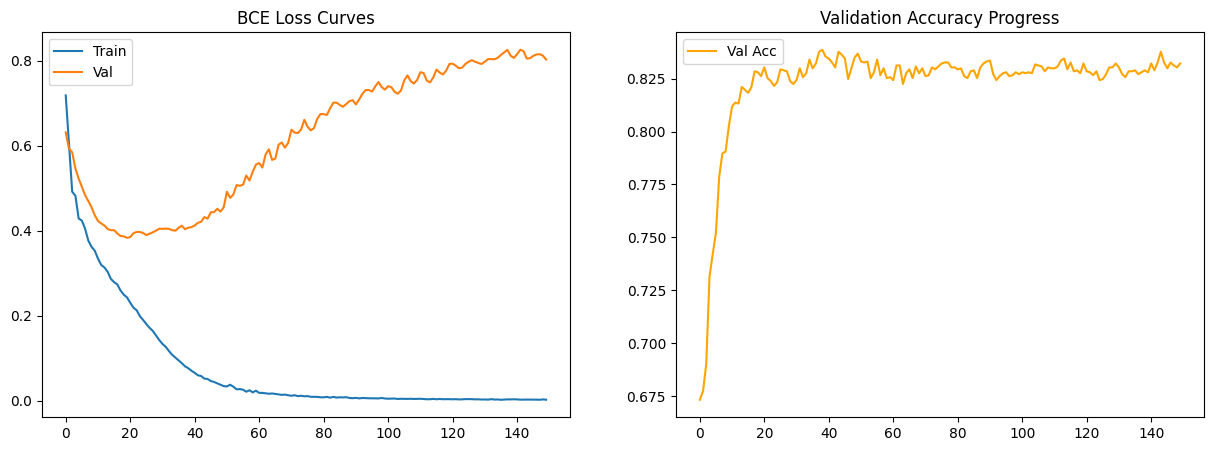


[HARVEST] NN Final Accuracy: 0.8261
[HARVEST] NN Final F1: 0.7972


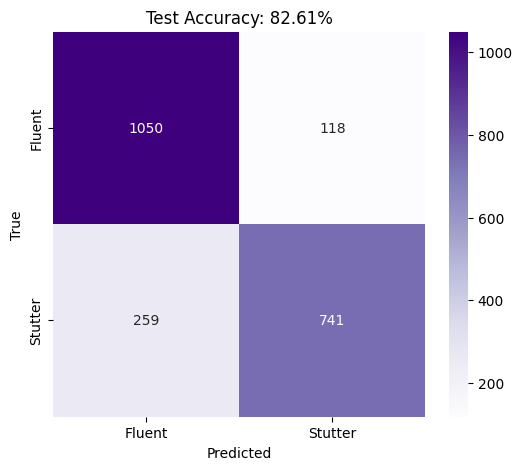

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_title('BCE Loss Curves')
ax1.legend()

ax2.plot(history['val_acc'], color='orange', label='Val Acc')
ax2.set_title('Validation Accuracy Progress')
ax2.legend()
plt.show()

advanced_model.eval()
with torch.no_grad():
    y_pred = (torch.sigmoid(advanced_model(torch.FloatTensor(X_test_final))) > 0.5).numpy().astype(int).flatten()
# HARVEST FOR LEADERBOARD
nn_final_accuracy = accuracy_score(y_test, y_pred)
nn_final_f1 = f1_score(y_test, y_pred) # Calculate F1
print(f"\n[HARVEST] NN Final Accuracy: {nn_final_accuracy:.4f}")
print(f"[HARVEST] NN Final F1: {nn_final_f1:.4f}")
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples', xticklabels=['Fluent', 'Stutter'], yticklabels=['Fluent', 'Stutter'])
plt.title(f'Test Accuracy: {nn_final_accuracy*100:.2f}%') # Percentage display
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## Step 8: Model Persistence

In [37]:
import os
os.makedirs("models", exist_ok=True)
torch.save(advanced_model.state_dict(), "models/stutternet_best.pth")
print("[System] Model exported successfully to models/stutternet_best.pth")


[System] Model exported successfully to models/stutternet_best.pth


--- Starting Optimization (150 Epochs) ---
Epoch 025 | Loss: 0.6606 | Val Acc: 0.5996
Epoch 050 | Loss: 0.6561 | Val Acc: 0.6098
Epoch 075 | Loss: 0.6557 | Val Acc: 0.6019
Epoch 100 | Loss: 0.6548 | Val Acc: 0.6001
Epoch 125 | Loss: 0.6542 | Val Acc: 0.6019
Epoch 150 | Loss: 0.6546 | Val Acc: 0.6038


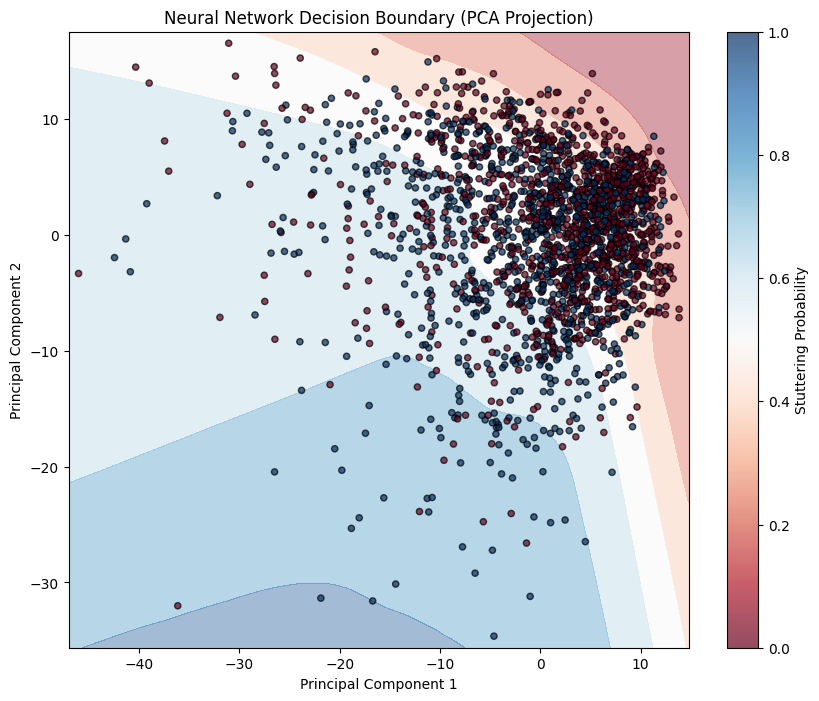

In [39]:
from sklearn.decomposition import PCA
import numpy as np

# 1. Dimensionality Reduction to 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_final)
X_test_pca = pca.transform(X_test_final)

# 2. Train a 2D Proxy Model
proxy_config = config.copy()
proxy_config["num_features"] = 2
proxy_model = AdvancedStutterNet(proxy_config)
train_stutternet(proxy_model, X_train_pca, y_train_bal, X_test_pca, y_test, proxy_config)

# 3. Create Meshgrid (Optimized step size)
h = .2 
x_min, x_max = X_test_pca[:, 0].min() - 1, X_test_pca[:, 0].max() + 1
y_min, y_max = X_test_pca[:, 1].min() - 1, X_test_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 4. Predict across the Mesh (Batch-wise to save memory)
proxy_model.eval()
grid_flat = np.c_[xx.ravel(), yy.ravel()]
Z_list = []
batch_size = 100000 
with torch.no_grad():
    for i in range(0, len(grid_flat), batch_size):
        batch = torch.FloatTensor(grid_flat[i:i+batch_size])
        Z_list.append(torch.sigmoid(proxy_model(batch)).numpy())
Z = np.vstack(Z_list).reshape(xx.shape)

# 5. Visualize
plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.4, cmap="RdBu")
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, edgecolor="k", s=20, cmap="RdBu", alpha=0.7)
plt.title("Neural Network Decision Boundary (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label="Stuttering Probability")
plt.show()
